# 06 — Hồi quy Chỉ số (Regression)

Dự đoán **huyết áp lúc nghỉ** (`trestbps`) từ các yếu tố nguy cơ.  
Mô hình: **Linear Regression**, **Ridge**, **XGBRegressor**  
Metric: **MAE**, **RMSE**  
Kiểm tra: outlier, leakage

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

from src import load_params
from src.data.loader import load_raw_data
from src.data.cleaner import handle_missing, binarize_target, encode_categorical
from src.models.regression import (
    prepare_regression_data, check_outliers_leakage,
    train_regression, plot_regression_results,
)

params = load_params()

## 6.1 Chuẩn bị dữ liệu hồi quy

In [2]:
# Đọc & làm sạch (giữ trestbps làm target hồi quy, không binarize)
df = load_raw_data(params)
df_clean = handle_missing(df, params)
df_clean, encoders = encode_categorical(df_clean, params)

X_reg, y_reg, reg_target = prepare_regression_data(df_clean, params)
X_reg.head()

[LOADER] Đọc thành công: 920 dòng × 16 cột
[CLEANER] Xử lý missing xong. Còn thiếu: 0
[CLEANER] Mã hóa 7 biến phân loại
[REGRESSION] Target: trestbps
  X shape: (920, 12), y shape: (920,)
  y stats: mean=132.00, std=18.45, min=0.0, max=200.0


,age,sex,cp,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63.0,1,3,233.0,1,0,150.0,0,2.3,0,0.0,0
1,67.0,1,0,286.0,0,0,108.0,1,1.5,1,3.0,1
2,67.0,1,0,229.0,0,0,129.0,1,2.6,1,2.0,2
3,37.0,1,2,250.0,0,1,187.0,0,3.5,0,0.0,1
4,41.0,0,1,204.0,0,0,172.0,0,1.4,2,0.0,1


## 6.2 Kiểm tra Outlier & Leakage

In [3]:
diag = check_outliers_leakage(X_reg, y_reg, reg_target, params)


──────────────────────────────────────────────────
KIỂM TRA OUTLIER & LEAKAGE
──────────────────────────────────────────────────
  Target 'trestbps': IQR=[120.0, 140.0], bounds=[90.0, 170.0]
  Outliers: 28 / 920 (3.0%)

  Top tương quan với 'trestbps':
    age: r = 0.2308
    oldpeak: r = 0.1612
    exang: r = 0.1538
    fbs: r = 0.1437
    thalch: r = 0.1047

  ✓ Không phát hiện leakage rõ ràng.


## 6.3 Huấn luyện mô hình hồi quy

Linear Regression, Ridge, XGBRegressor — CV 5-fold, MAE & RMSE.

In [4]:
reg_results = train_regression(X_reg, y_reg, params)


HUẤN LUYỆN MÔ HÌNH HỒI QUY

--- LinearRegression ---
  CV MAE: 13.6911 (±0.7877)
  CV RMSE: 17.9915 (±1.1274)
  Train MAE: 13.2168, Train RMSE: 17.5144
  Train time: 0.05s

--- Ridge ---
  CV MAE: 13.6866 (±0.7899)
  CV RMSE: 17.9879 (±1.1292)
  Train MAE: 13.2162, Train RMSE: 17.5144
  Train time: 0.03s

--- XGBRegressor ---
  CV MAE: 15.5560 (±1.4340)
  CV RMSE: 20.7926 (±2.1521)
  Train MAE: 5.4434, Train RMSE: 7.7925
  Train time: 1.00s

BẢNG TỔNG HỢP HỒI QUY
         Mô hình  CV MAE (mean)  CV MAE (std)  CV RMSE (mean)  CV RMSE (std)  Train MAE  Train RMSE  Thời gian (s)
LinearRegression        13.6911        0.7877         17.9915         1.1274    13.2168     17.5144           0.05
           Ridge        13.6866        0.7899         17.9879         1.1292    13.2162     17.5144           0.03
    XGBRegressor        15.5560        1.4340         20.7926         2.1521     5.4434      7.7925           1.00


## 6.4 Biểu đồ đánh giá

Actual vs Predicted, Residual Plot, Feature Importance (XGBRegressor).

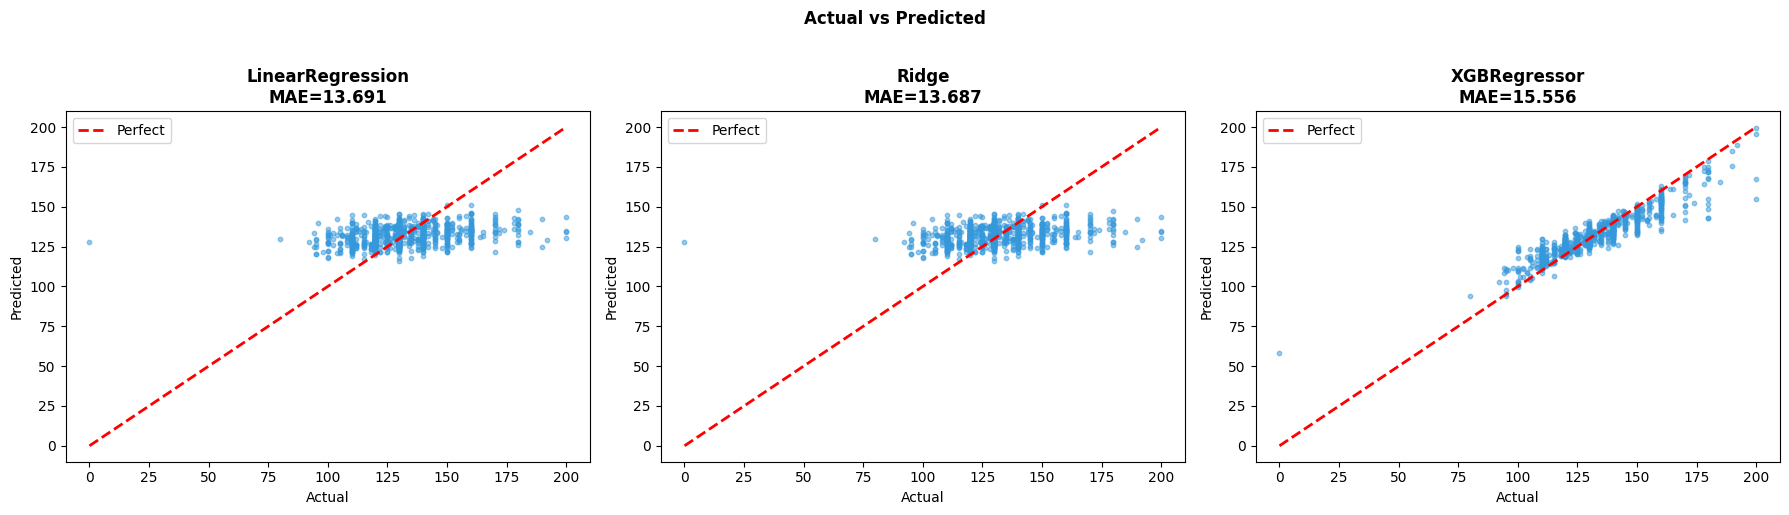

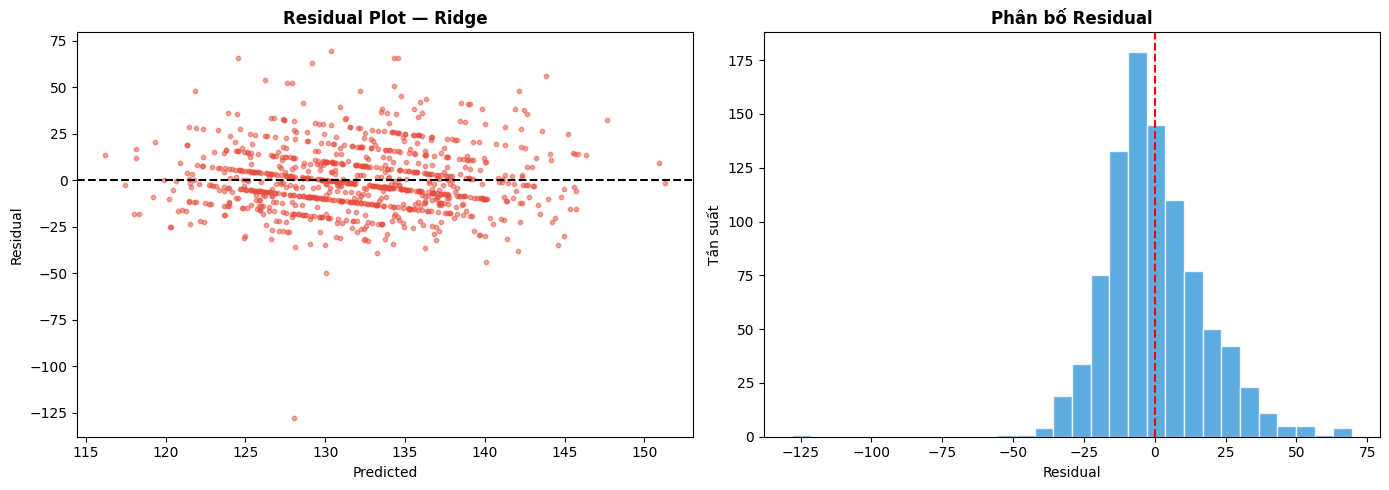

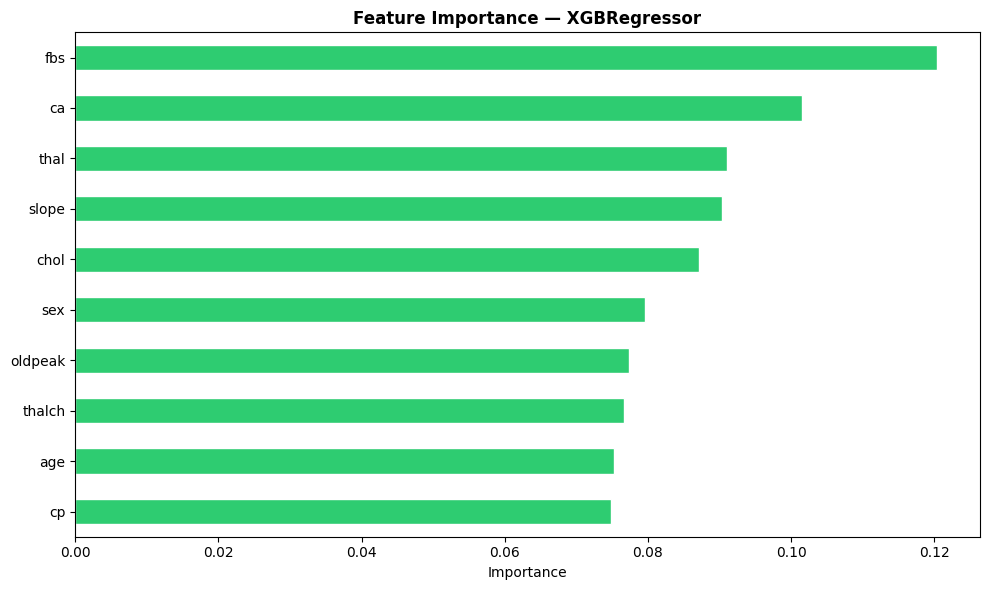

In [5]:
plot_regression_results(reg_results, X_reg, y_reg, params)

## 6.5 Diễn giải & Kết luận Hồi quy

### Kết quả mô hình
- **Linear Regression** và **Ridge** cho kết quả gần như tương đương (MAE ~13.7, RMSE ~18.0)
  - → Không có multicollinearity nghiêm trọng (Ridge penalty không giúp nhiều)
- **XGBRegressor** có Train MAE rất thấp (~5.4) nhưng CV MAE cao hơn (~15.6)
  - → **Overfitting rõ ràng** → cần tăng regularization hoặc giảm n_estimators

### Phân tích biểu đồ
- **Actual vs Predicted:** Scatter phân tán xung quanh đường perfect → mô hình dự đoán xu hướng chung nhưng sai số lớn
- **Residual plot:** Residual phân bố đối xứng quanh 0 → không có bias hệ thống
- **Feature Importance (XGB):** `age` là yếu tố quan trọng nhất → tuổi ảnh hưởng mạnh đến huyết áp (y khoa hợp lệ)

### Nhận xét y khoa
- Huyết áp lúc nghỉ phụ thuộc nhiều yếu tố ngoài 12 features hiện tại (chế độ ăn, thuốc, stress, BMI...)
- MAE ~14 mmHg trên dải 90–200 mmHg → sai số ~10% → **chưa đủ chính xác cho lâm sàng**
- Mô hình hồi quy phù hợp hơn cho **ước lượng xu hướng** (screening) hơn là dự đoán chính xác

### Bài học
1. Regression trên dữ liệu y khoa khó hơn classification vì biến liên tục phụ thuộc nhiều yếu tố unmeasured
2. Kiểm tra leakage quan trọng — không có feature nào tương quan > 0.95 với target → an toàn
3. Ridge regression ổn định hơn XGBoost cho dataset nhỏ → ưu tiên đơn giản khi dữ liệu hạn chế